In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('superstore.csv', encoding='latin1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_') for c in df.columns]
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%m/%d/%Y')

print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print("\nDuplicate rows:", df.duplicated().sum())
print("\nColumns:", list(df.columns))

Missing values per column:
None

Duplicate rows: 0

Columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [4]:
df.to_csv('superstore_cleaned.csv', index=False)
print("Saved cleaned dataset -> superstore_cleaned.csv", df.shape)

Saved cleaned dataset -> superstore_cleaned.csv (9994, 21)


## Task 1 — Univariate, properly read

Histogram + KDE of `sales`, its skewness, and mean vs. median.

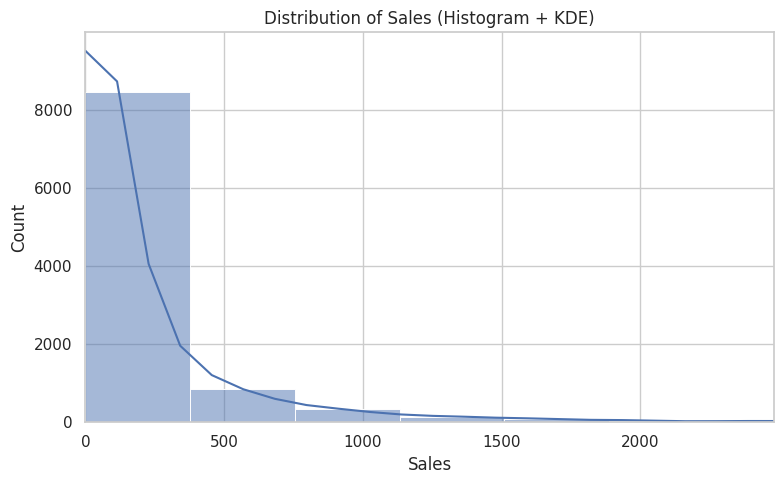

Skewness of sales: 12.97
Mean sales:   229.86
Median sales: 54.49


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df['sales'], kde=True, bins=60, ax=ax, color='#4C72B0')
ax.set_title('Distribution of Sales (Histogram + KDE)')
ax.set_xlabel('Sales')
ax.set_ylabel('Count')
ax.set_xlim(0, df['sales'].quantile(0.99))
plt.tight_layout()
plt.show()

skew = df['sales'].skew()
mean_s = df['sales'].mean()
median_s = df['sales'].median()
print(f"Skewness of sales: {skew:.2f}")
print(f"Mean sales:   {mean_s:.2f}")
print(f"Median sales: {median_s:.2f}")

**Interpretation:** Sales skewness is about **13** (mean ≈ **229.9** is roughly **4×** the median ≈ **54.5**), so the distribution is heavily **right-skewed** — most orders are small, with a long tail of a few large-value orders pulling the mean up. That makes the mean a poor summary of a "typical" order here; the median (or a trimmed/log-scale summary) better represents the bulk of the transactions.

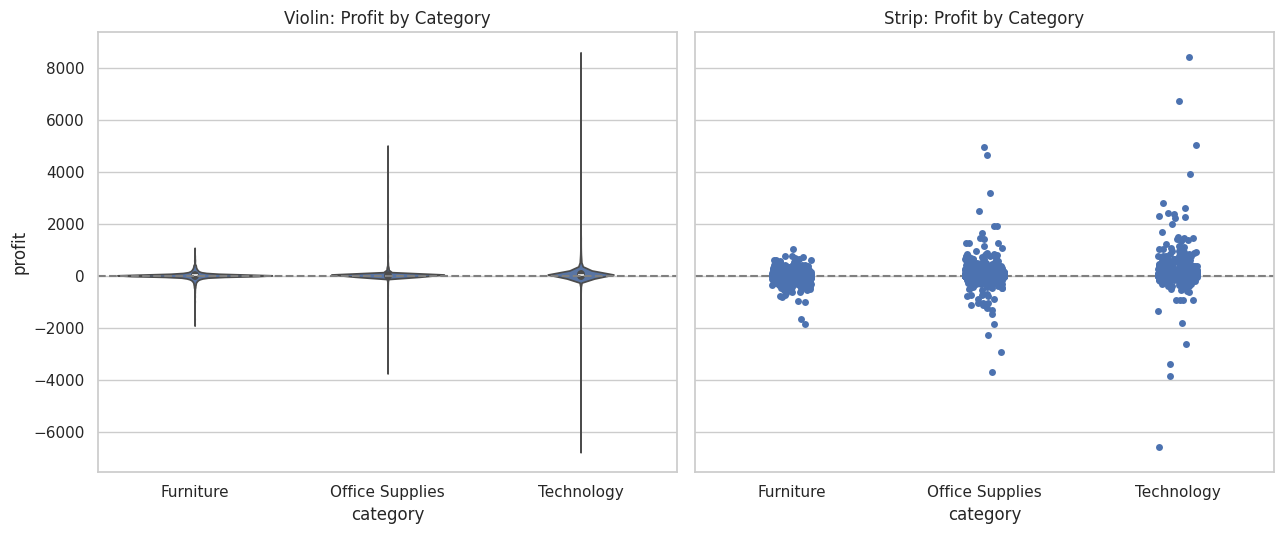

                  mean  median     std  skew
category                                    
Furniture         8.70    7.77  136.05 -2.29
Office Supplies  20.33    6.88  164.89  7.03
Technology       78.75   25.02  428.82  5.15


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

sns.violinplot(data=df, x='category', y='profit', ax=axes[0])
axes[0].set_title('Violin: Profit by Category')
axes[0].axhline(0, color='grey', linestyle='--')

sns.stripplot(data=df, x='category', y='profit', ax=axes[1], jitter=True)
axes[1].set_title('Strip: Profit by Category')
axes[1].axhline(0, color='grey', linestyle='--')

plt.tight_layout()
plt.show()

print(df.groupby('category')['profit'].agg(['mean', 'median', 'std', 'skew']).round(2))

**Which plot reveals it better?** The **violin plot** is the one that surfaces the shape problem: **Technology** shows the widest, most stretched density (std ≈ 429) with mass pulled toward a long positive tail alongside a visible loss-side bulge, and **Office Supplies** shows a sharply peaked, right-skewed density (skew ≈ 7). The strip plot shows the same raw points, but with ~6,000+ overlapping Office Supplies orders jittered on top of each other, the density shape is harder to read by eye than in the violin's smoothed outline — strip plots are better at showing exact sample size per category than at exposing bimodality/spread.

## Task 3 — Multivariate encoding

Single scatter of `discount` vs. `profit`, encoding `category` via hue and `sales` via point size.

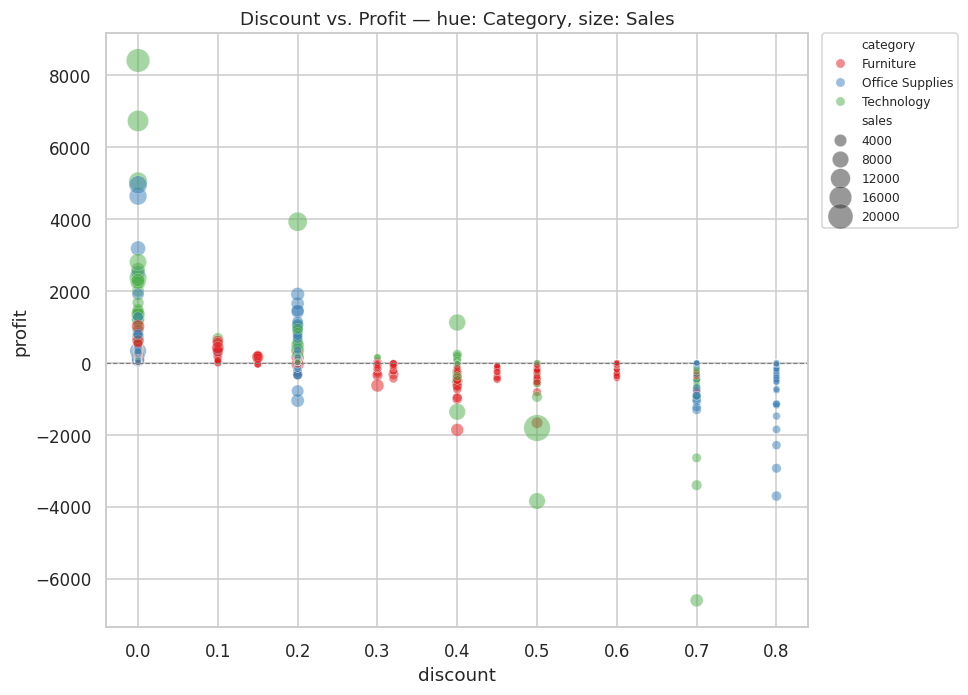

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6.5))
sns.scatterplot(
    data=df, x='discount', y='profit', hue='category', size='sales',
    sizes=(15, 300), alpha=0.5, palette='Set1', ax=ax
)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Discount vs. Profit — hue: Category, size: Sales')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=8)
plt.tight_layout()
plt.show()

**Pattern only visible with the 4-variable encoding:** the biggest losses (points far below the zero line) are disproportionately **large Technology points at high discount** — i.e. it's specifically big-ticket, heavily-discounted Technology orders that drive the worst losses, not just "high discount" in general. A plain 2-variable discount-vs-profit scatter would show the same downward spread, but without size+hue you couldn't tell that large, high-value orders are the ones responsible for the deepest losses, nor that the pattern concentrates in one category.

## Task 4 — Correlation: Pearson vs. Spearman

In [ ]:
num_cols = ['sales', 'quantity', 'discount', 'profit']
pearson_corr = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')

print("Pearson:\n", pearson_corr.round(3))
print("\nSpearman:\n", spearman_corr.round(3))

diff = (pearson_corr - spearman_corr).abs().copy()
vals = diff.to_numpy().copy()
np.fill_diagonal(vals, 0)
diff = pd.DataFrame(vals, index=diff.index, columns=diff.columns)
print("\nLargest Pearson - Spearman gaps:")
print(diff.stack().sort_values(ascending=False).drop_duplicates().head(5))

Pearson:
           sales  quantity  discount  profit
sales     1.000     0.201    -0.028   0.479
quantity  0.201     1.000     0.009   0.066
discount -0.028     0.009     1.000  -0.219
profit    0.479     0.066    -0.219   1.000

Spearman:
           sales  quantity  discount  profit
sales     1.000     0.327    -0.057   0.518
quantity  0.327     1.000    -0.001   0.234
discount -0.057    -0.001     1.000  -0.543
profit    0.518     0.234    -0.543   1.000

Largest |Pearson - Spearman| gaps:
profit    discount    0.323863
quantity  profit      0.168238
          sales       0.126631
profit    sales       0.039342
discount  sales       0.028778
dtype: float64


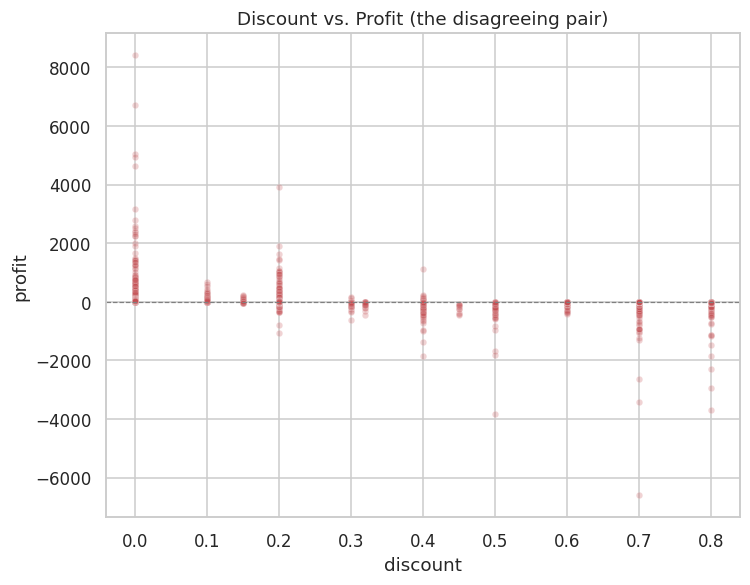

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=df, x='discount', y='profit', alpha=0.25, s=18, ax=ax, color='#C44E52')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Discount vs. Profit (the disagreeing pair)')
plt.tight_layout()
plt.show()

**Where they disagree:** `discount` vs. `profit` is the clearest gap — Pearson r ≈ **-0.22** (weak) vs. Spearman ρ ≈ **-0.54** (moderate-to-strong). The scatter shows why: the relationship is **not linear** — profit stays roughly flat and mildly positive at low discounts, then drops sharply and consistently negative once discount exceeds roughly 0.3–0.4, with heavy-loss outliers at the highest discount tiers. Pearson tries to fit a single straight line through that bend-plus-outliers and understates the relationship; Spearman, working on ranks, is robust to both the outliers and the non-linearity and correctly picks up the strong *monotonic* (higher discount → lower profit) pattern.

**Correlation ≠ causation:** even a strong Spearman correlation here only shows that discount and profit move together in rank order — it does not by itself prove that discounting *causes* the loss (e.g., discounts might be applied selectively to slow-moving or already low-margin items, which would produce the same pattern without discount being the sole driver).

## Task 5 — Layered aggregation: region × category pivot heatmap

category  Furniture  Office Supplies  Technology        All
region                                                     
Central    163797.0         167026.0    170416.0   501240.0
East       208291.0         205516.0    264974.0   678781.0
South      117299.0         125651.0    148772.0   391722.0
West       252613.0         220853.0    251992.0   725458.0
All        742000.0         719047.0    836154.0  2297201.0


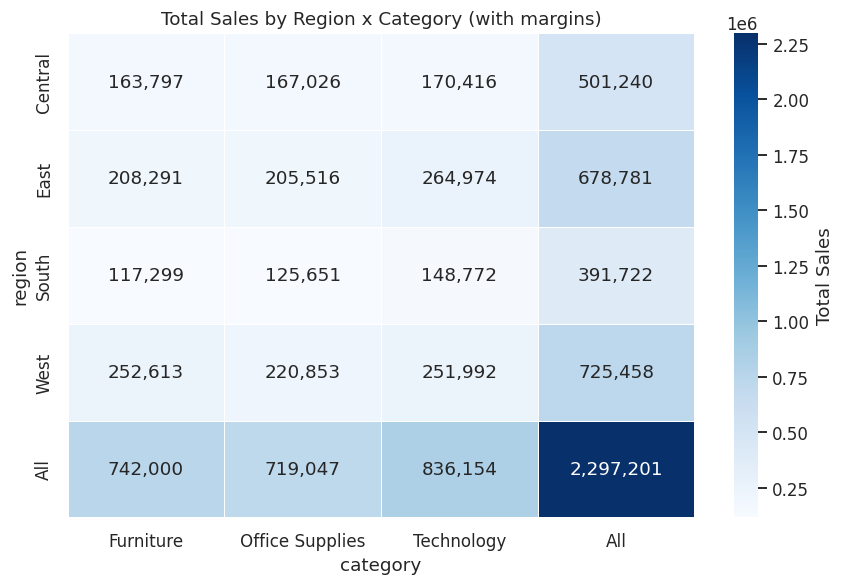

In [ ]:
pivot_sales = pd.pivot_table(
    df, index='region', columns='category', values='sales',
    aggfunc='sum', margins=True, margins_name='All'
)
print(pivot_sales.round(0))

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(pivot_sales, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Total Sales'})
ax.set_title('Total Sales by Region x Category (with margins)')
plt.tight_layout()
plt.show()

In [ ]:
top_cell = pivot_sales.drop('All').drop(columns='All').stack().idxmax()
top_val = pivot_sales.drop('All').drop(columns='All').stack().max()
print(f"Top region-category combination: {top_cell} -> {top_val:,.0f}")

Top region-category combination: ('East', 'Technology') -> 264,974


**Biggest contributor:** **East–Technology** is the single highest-revenue region-category cell (≈ **265,000** in total sales), narrowly ahead of West-Furniture and West-Technology. At the region level, **West** has the highest overall total (from the `All` column), but the single densest revenue cell in the whole table is East's Technology sales.

## Task 6 — Time series: trend vs. noise

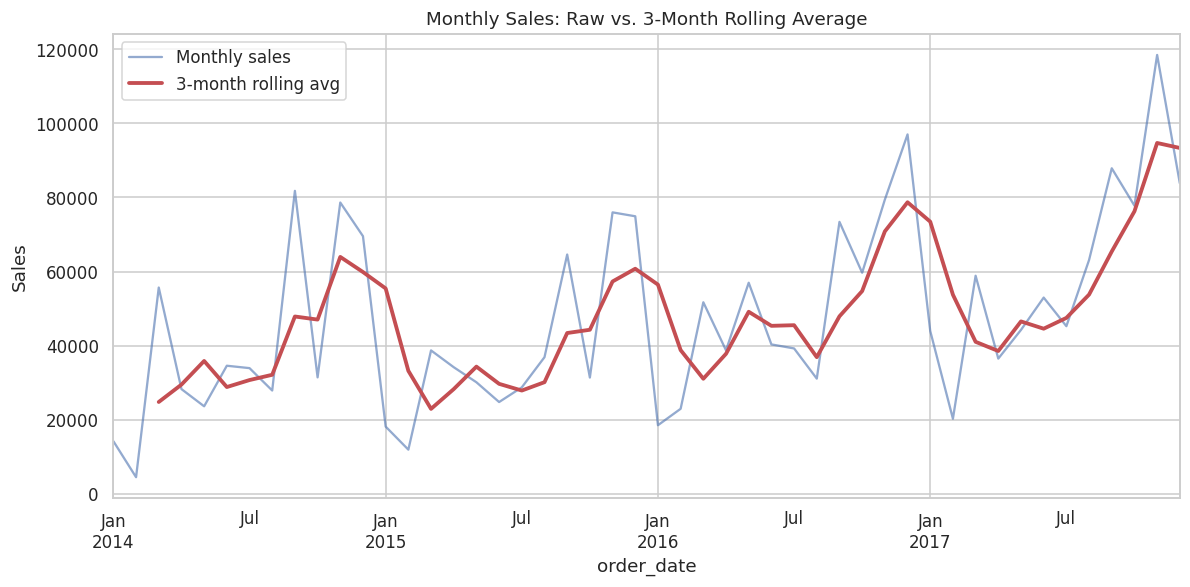

In [ ]:
ts = df.set_index('order_date').sort_index()
monthly = ts['sales'].resample('ME').sum()
rolling = monthly.rolling(window=3).mean()

fig, ax = plt.subplots(figsize=(11, 5.5))
monthly.plot(ax=ax, label='Monthly sales', color='#4C72B0', alpha=0.6)
rolling.plot(ax=ax, label='3-month rolling avg', color='#C44E52', linewidth=2.5)
ax.set_title('Monthly Sales: Raw vs. 3-Month Rolling Average')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

**What the rolling average reveals:** the raw monthly line swings sharply month to month (large dips in Jan/Feb of each year, sharp spikes around Nov/Dec), which mostly reflects short-term seasonal noise rather than the underlying business trajectory. The 3-month rolling average smooths those swings out and makes the **steady year-over-year upward trend** in Superstore's sales clearly visible — something that's hard to see in the raw line because it's dominated by the seasonal noise.

## Task 7 — Faceting: discount vs. profit by region and profitability

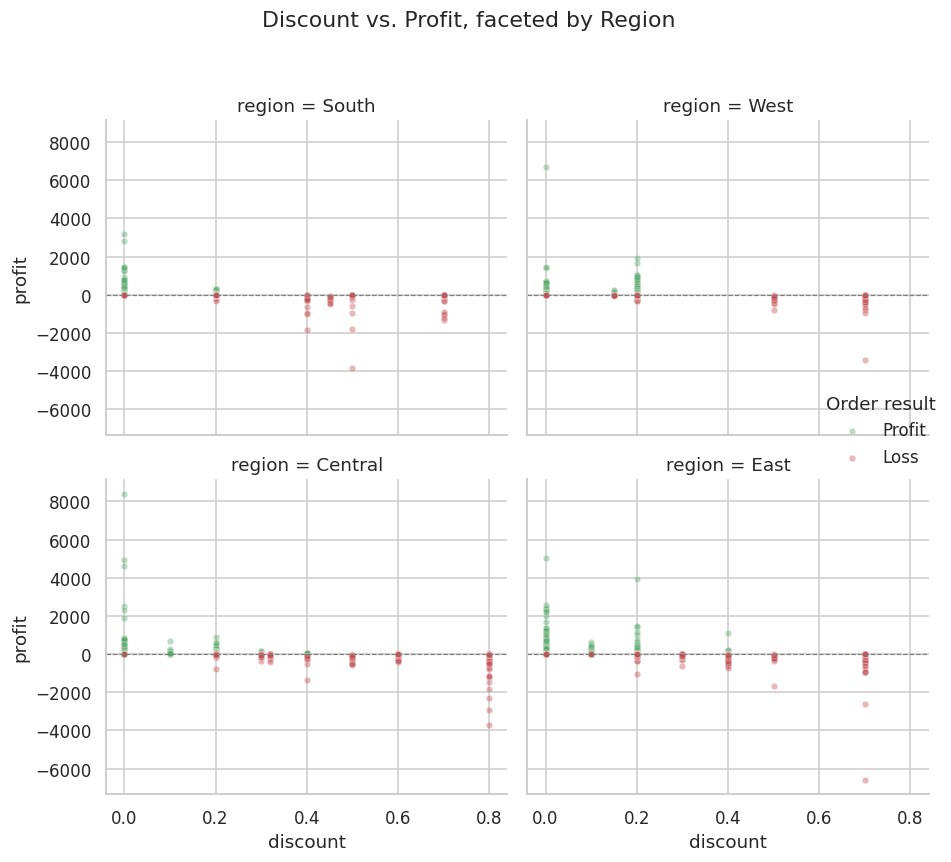

In [ ]:
df['profitable'] = np.where(df['profit'] > 0, 'Profit', 'Loss')

g = sns.FacetGrid(df, col='region', hue='profitable', col_wrap=2, height=3.8,
                   palette={'Profit': '#55A868', 'Loss': '#C44E52'})
g.map(sns.scatterplot, 'discount', 'profit', alpha=0.4, s=18)
for ax in g.axes.flat:
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
g.add_legend(title='Order result')
g.fig.suptitle('Discount vs. Profit, faceted by Region', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
loss_rate_by_region = df.groupby('region')['profitable'].apply(lambda s: (s == 'Loss').mean() * 100).round(1)
corr_by_region = df.groupby('region').apply(lambda d: d['discount'].corr(d['profit']), include_groups=False).round(3)
print("Loss rate by region (%):\n", loss_rate_by_region)
print("\nDiscount-profit correlation by region:\n", corr_by_region)

Loss rate by region (%):
 region
Central    32.4
East       20.1
South      16.8
West       10.6
Name: profitable, dtype: float64

Discount-profit correlation by region:
 region
Central   -0.225
East      -0.226
South     -0.272
West      -0.155
dtype: float64


**Region that stands out:** **Central** visibly differs from the rest — nearly **32%** of its orders are losses (vs. roughly 10–19% elsewhere), and its loss points are spread across a wider range of discount levels rather than being concentrated only at the highest discounts like in South or East. Central shows losses creeping in even at moderate discounts, suggesting a weaker discount-profit relationship there than the "losses only at steep discounts" pattern in the other regions.

## Task 8 — Overplotting + annotation, combined

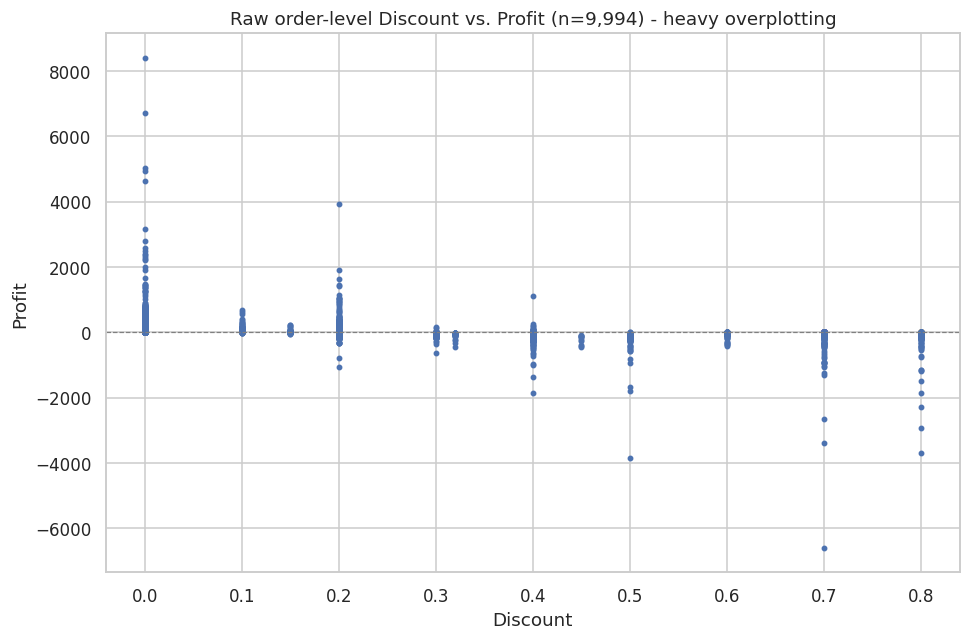

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['discount'], df['profit'], s=8, color='#4C72B0')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title(f'Raw order-level Discount vs. Profit (n={len(df):,}) - heavy overplotting')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

With **9,994** points on a scatter, this is a moderate-sized dataset rather than a 50k+ "hexbin" case, and both axes are continuous rather than discrete-integer (so jitter isn't the right fix either) — **alpha transparency** is the appropriate fix here since it keeps individual outliers visible while revealing where points actually pile up.

Highest-profit order: CA-2016-118689 | discount=0.0 | profit=8399.98 | category=Technology
Largest-loss order:  CA-2016-108196 | discount=0.7 | profit=-6599.98 | category=Technology


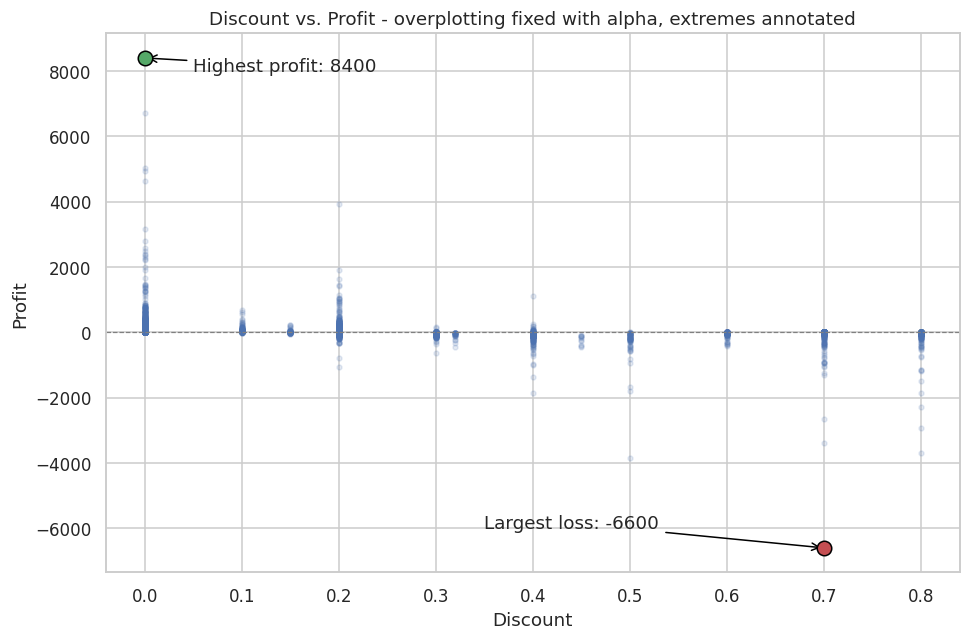

In [ ]:
best = df.loc[df['profit'].idxmax()]
worst = df.loc[df['profit'].idxmin()]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df['discount'], df['profit'], s=10, alpha=0.15, color='#4C72B0')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

ax.scatter(best['discount'], best['profit'], color='#55A868', s=90, zorder=5, edgecolor='black')
ax.annotate(f"Highest profit: {best['profit']:.0f}",
            xy=(best['discount'], best['profit']),
            xytext=(best['discount'] + 0.05, best['profit'] - 400),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.scatter(worst['discount'], worst['profit'], color='#C44E52', s=90, zorder=5, edgecolor='black')
ax.annotate(f"Largest loss: {worst['profit']:.0f}",
            xy=(worst['discount'], worst['profit']),
            xytext=(worst['discount'] - 0.35, worst['profit'] + 600),
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_title('Discount vs. Profit - overplotting fixed with alpha, extremes annotated')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit')
plt.tight_layout()
plt.show()

print(f"Highest-profit order: {best['order_id']} | discount={best['discount']} | profit={best['profit']:.2f} | category={best['category']}")
print(f"Largest-loss order:  {worst['order_id']} | discount={worst['discount']} | profit={worst['profit']:.2f} | category={worst['category']}")

## Summary

| Task | Key finding |
|---|---|
| 1. Univariate | `sales` is strongly right-skewed (skew ≈ 13); median is a better "typical order" summary than the mean |
| 2. Cat x Num | Violin plot best exposes Technology's wide/stretched profit spread and Office Supplies' sharp positive skew |
| 3. Multivariate | Largest losses are concentrated in large, heavily-discounted **Technology** orders |
| 4. Correlation | Discount-profit relationship is monotonic but non-linear; Spearman (-0.54) picks it up, Pearson (-0.22) understates it |
| 5. Aggregation | East-Technology is the single highest-revenue region-category cell |
| 6. Time-series | 3-month rolling average reveals a steady upward trend hidden by monthly seasonal noise |
| 7. Faceting | Central region has a notably higher loss rate (~32%) spread across a wider discount range |
| 8. Overplotting | Alpha transparency (fits n≈10k) resolves the blob; extremes annotated directly on the chart |

**Caveat:** all correlations and patterns above describe association, not causation.